In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

In [4]:
# ══════════════════════════════════════════════════════════════
# LOAD ALL RESULTS
# ══════════════════════════════════════════════════════════════
with open("../results/metrics/ml_results.json", "r") as f:
    ml_results = json.load(f)

with open("../results/metrics/deep_results.json", "r") as f:
    deep_results = json.load(f)

with open("../results/metrics/transformer_results.json", "r") as f:
    transformer_results = json.load(f)



print("✅ All results loaded!")

✅ All results loaded!


In [5]:
# ══════════════════════════════════════════════════════════════
# BUILD SUMMARY TABLE
# ══════════════════════════════════════════════════════════════
# Fill with your actual scores from each notebook
# pretrain = synthetic test, finetune = real test

summary = {
    # ── Traditional ML ────────────────────────────────────────
    "Logistic_Regression": {
        "type":          "Traditional ML",
        "pretrain_f1":   ml_results["pretrain"]["Logistic_Regression"]["f1"],
        "pretrain_acc":  ml_results["pretrain"]["Logistic_Regression"]["accuracy"],
        "finetune_f1":   ml_results["finetune"]["Logistic_Regression"]["f1"],
        "finetune_acc":  ml_results["finetune"]["Logistic_Regression"]["accuracy"],
    },
    "Random_Forest": {
        "type":          "Traditional ML",
        "pretrain_f1":   ml_results["pretrain"]["Random_Forest"]["f1"],
        "pretrain_acc":  ml_results["pretrain"]["Random_Forest"]["accuracy"],
        "finetune_f1":   ml_results["finetune"]["Random_Forest"]["f1"],
        "finetune_acc":  ml_results["finetune"]["Random_Forest"]["accuracy"],
    },
    "XGBoost": {
        "type":          "Traditional ML",
        "pretrain_f1":   ml_results["pretrain"]["XGBoost"]["f1"],
        "pretrain_acc":  ml_results["pretrain"]["XGBoost"]["accuracy"],
        "finetune_f1":   ml_results["finetune"]["XGBoost"]["f1"],
        "finetune_acc":  ml_results["finetune"]["XGBoost"]["accuracy"],
    },
    "Ensemble": {
        "type":          "Traditional ML",
        "pretrain_f1":   ml_results["pretrain"]["Ensemble"]["f1"],
        "pretrain_acc":  ml_results["pretrain"]["Ensemble"]["accuracy"],
        "finetune_f1":   ml_results["finetune"]["Ensemble"]["f1"],
        "finetune_acc":  ml_results["finetune"]["Ensemble"]["accuracy"],
    },

    # ── Deep NN ───────────────────────────────────────────────
    "BiLSTM": {
        "type":          "Deep NN",
        "pretrain_f1":   deep_results["pretrain"]["BiLSTM"]["f1"],
        "pretrain_acc":  deep_results["pretrain"]["BiLSTM"]["accuracy"],
        "finetune_f1":   deep_results["finetune"]["BiLSTM"]["f1"],
        "finetune_acc":  deep_results["finetune"]["BiLSTM"]["accuracy"],
    },
    "BiLSTM_Attn": {
        "type":          "Deep NN",
        "pretrain_f1":   deep_results["pretrain"]["BiLSTM_Attn"]["f1"],
        "pretrain_acc":  deep_results["pretrain"]["BiLSTM_Attn"]["accuracy"],
        "finetune_f1":   deep_results["finetune"]["BiLSTM_Attn"]["f1"],
        "finetune_acc":  deep_results["finetune"]["BiLSTM_Attn"]["accuracy"],
    },
    "CNN_BiLSTM": {
        "type":          "Deep NN",
        "pretrain_f1":   deep_results["pretrain"]["CNN_BiLSTM"]["f1"],
        "pretrain_acc":  deep_results["pretrain"]["CNN_BiLSTM"]["accuracy"],
        "finetune_f1":   deep_results["finetune"]["CNN_BiLSTM"]["f1"],
        "finetune_acc":  deep_results["finetune"]["CNN_BiLSTM"]["accuracy"],
    },

    # ── Transformers ──────────────────────────────────────────
    "mBERT": {
        "type":          "Transformer",
        "pretrain_f1":   transformer_results["mBERT"]["pretrain"]["f1"],
        "pretrain_acc":  transformer_results["mBERT"]["pretrain"]["accuracy"],
        "finetune_f1":   transformer_results["mBERT"]["finetune"]["f1"],
        "finetune_acc":  transformer_results["mBERT"]["finetune"]["accuracy"],
     
    },
    "XLM_RoBERTa": {
        "type":          "Transformer",
        "pretrain_f1":   transformer_results["XLM_RoBERTa"]["pretrain"]["f1"],
        "pretrain_acc":  transformer_results["XLM_RoBERTa"]["pretrain"]["accuracy"],
        "finetune_f1":   transformer_results["XLM_RoBERTa"]["finetune"]["f1"],
        "finetune_acc":  transformer_results["XLM_RoBERTa"]["finetune"]["accuracy"],
    },
       
}

In [6]:
# ── Print summary table ───────────────────────────────────────
print("\n" + "="*75)
print("  COMPLETE MODEL COMPARISON")
print("="*75)
print(f"{'Model':<20} {'Type':<16} {'Pre_F1':>8} "
      f"{'FT_F1':>8} {'Δ F1':>8}")
print("-"*75)

for name, s in summary.items():
    pre = s["pretrain_f1"]
    ft  = s["finetune_f1"]
    delta = ft - pre
    arrow = "↑" if delta > 0 else "↓"
    print(f"  {name:<18} {s['type']:<16} "
          f"{pre:>8.4f} {ft:>8.4f} "
          f"{arrow}{abs(delta):>6.4f}")


  COMPLETE MODEL COMPARISON
Model                Type               Pre_F1    FT_F1     Δ F1
---------------------------------------------------------------------------
  Logistic_Regression Traditional ML     0.9665   0.9629 ↓0.0036
  Random_Forest      Traditional ML     0.9688   0.9762 ↑0.0074
  XGBoost            Traditional ML     0.9531   0.9683 ↑0.0151
  Ensemble           Traditional ML     0.9710   0.9735 ↑0.0026
  BiLSTM             Deep NN            0.9241   0.8989 ↓0.0252
  BiLSTM_Attn        Deep NN            0.9486   0.8588 ↓0.0898
  CNN_BiLSTM         Deep NN            0.9464   0.9072 ↓0.0392
  mBERT              Transformer        0.9978   0.9921 ↓0.0057
  XLM_RoBERTa        Transformer        0.9955   0.9868 ↓0.0088


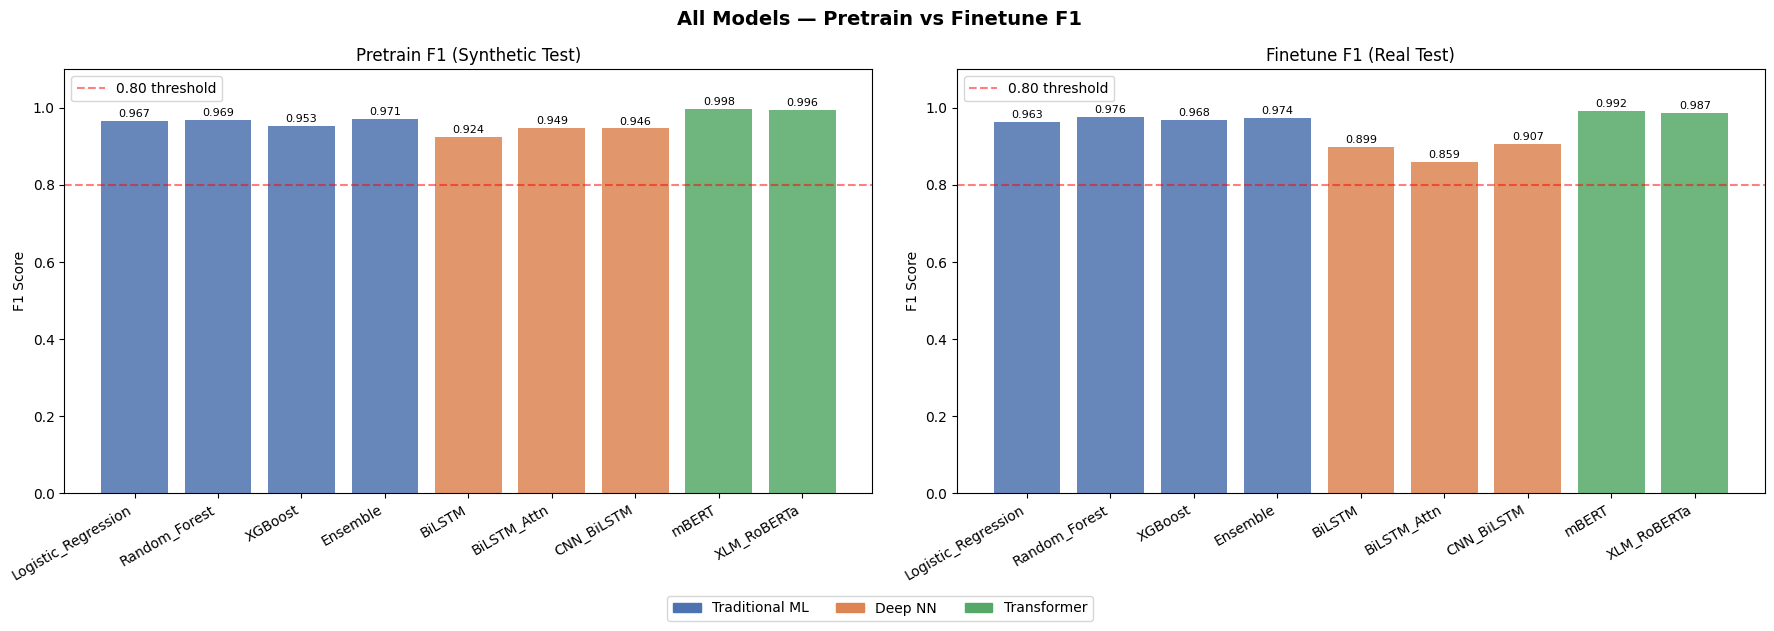

✅ Saved → all_models_f1_comparison.png


In [7]:
# ══════════════════════════════════════════════════════════════
# PLOT 1 — PRETRAIN F1 COMPARISON (ALL MODELS)
# ══════════════════════════════════════════════════════════════
def get_color(model_type):
    return {
        "Traditional ML": "#4C72B0",
        "Deep NN":        "#DD8452",
        "Transformer":    "#55A868",
    }[model_type]

names      = list(summary.keys())
pre_f1s    = [summary[n]["pretrain_f1"]  for n in names]
ft_f1s     = [summary[n]["finetune_f1"]  for n in names]
colors     = [get_color(summary[n]["type"]) for n in names]

x     = np.arange(len(names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    "All Models — Pretrain vs Finetune F1",
    fontsize=14, fontweight="bold"
)

# Pretrain F1
bars1 = axes[0].bar(x, pre_f1s, color=colors, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Pretrain F1 (Synthetic Test)")
axes[0].set_ylabel("F1 Score")
axes[0].axhline(y=0.8, color="red", linestyle="--",
                alpha=0.5, label="0.80 threshold")
axes[0].legend()
for bar, val in zip(bars1, pre_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=8)

# Finetune F1
bars2 = axes[1].bar(x, ft_f1s, color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha="right")
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Finetune F1 (Real Test)")
axes[1].set_ylabel("F1 Score")
axes[1].axhline(y=0.8, color="red", linestyle="--",
                alpha=0.5, label="0.80 threshold")
axes[1].legend()
for bar, val in zip(bars2, ft_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=8)

# Legend for model types
legend_patches = [
    mpatches.Patch(color="#4C72B0", label="Traditional ML"),
    mpatches.Patch(color="#DD8452", label="Deep NN"),
    mpatches.Patch(color="#55A868", label="Transformer"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("../results/figures/all_models_f1_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → all_models_f1_comparison.png")

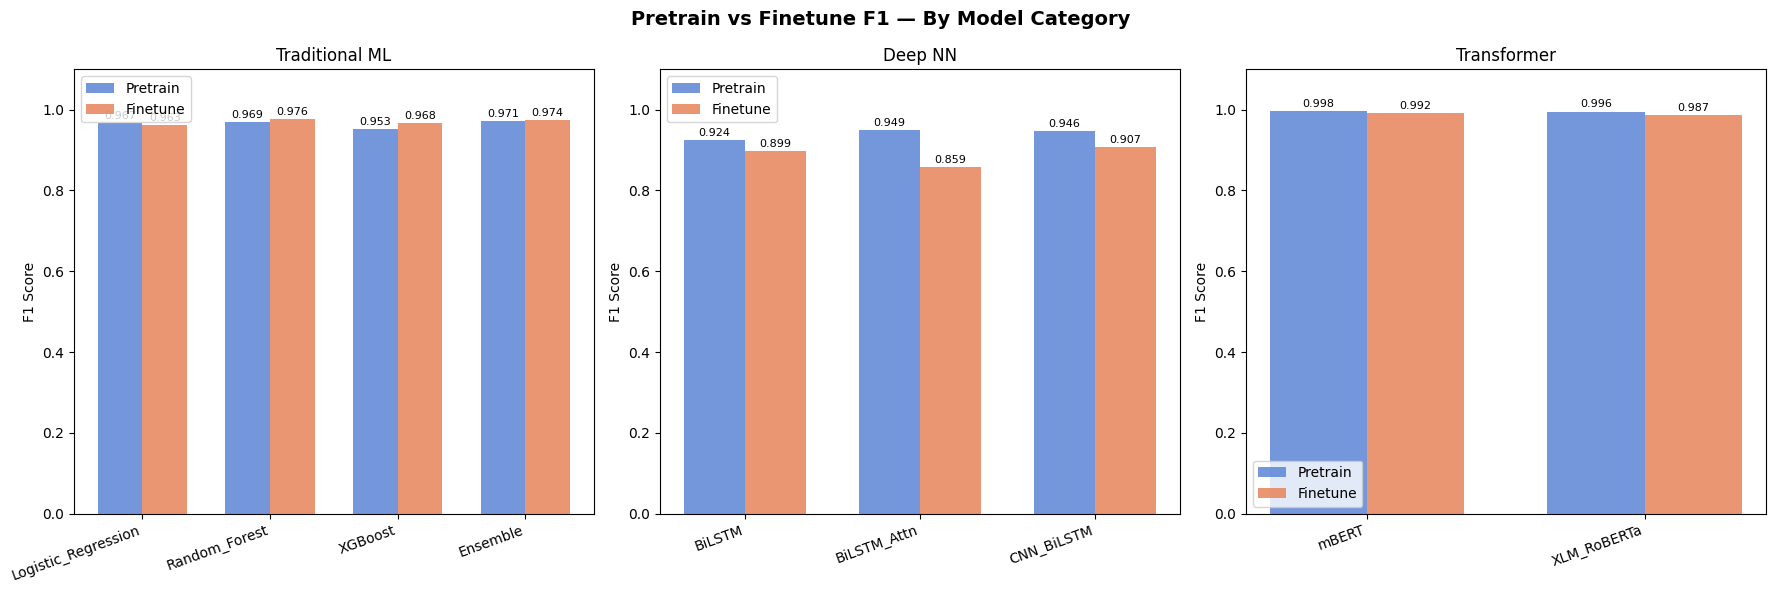

✅ Saved → comparison_by_category.png


In [8]:
# ══════════════════════════════════════════════════════════════
# PLOT 2 — PRETRAIN vs FINETUNE GROUPED BY TYPE
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Pretrain vs Finetune F1 — By Model Category",
    fontsize=14, fontweight="bold"
)

categories = {
    "Traditional ML": ["Logistic_Regression", "Random_Forest",
                       "XGBoost", "Ensemble"],
    "Deep NN":        ["BiLSTM", "BiLSTM_Attn", "CNN_BiLSTM"],
    "Transformer":    ["mBERT", "XLM_RoBERTa"],
}

for ax, (cat, model_list) in zip(axes, categories.items()):
    cat_pre = [summary[m]["pretrain_f1"] for m in model_list]
    cat_ft  = [summary[m]["finetune_f1"] for m in model_list]
    x       = np.arange(len(model_list))
    width   = 0.35

    bars_pre = ax.bar(x - width/2, cat_pre, width,
                      label="Pretrain", color="#5C85D6", alpha=0.85)
    bars_ft  = ax.bar(x + width/2, cat_ft,  width,
                      label="Finetune", color="#E8845A", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(model_list, rotation=20, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_title(cat)
    ax.set_ylabel("F1 Score")
    ax.legend()

    for bar, val in zip(bars_pre, cat_pre):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=8)
    for bar, val in zip(bars_ft, cat_ft):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../results/figures/comparison_by_category.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → comparison_by_category.png")

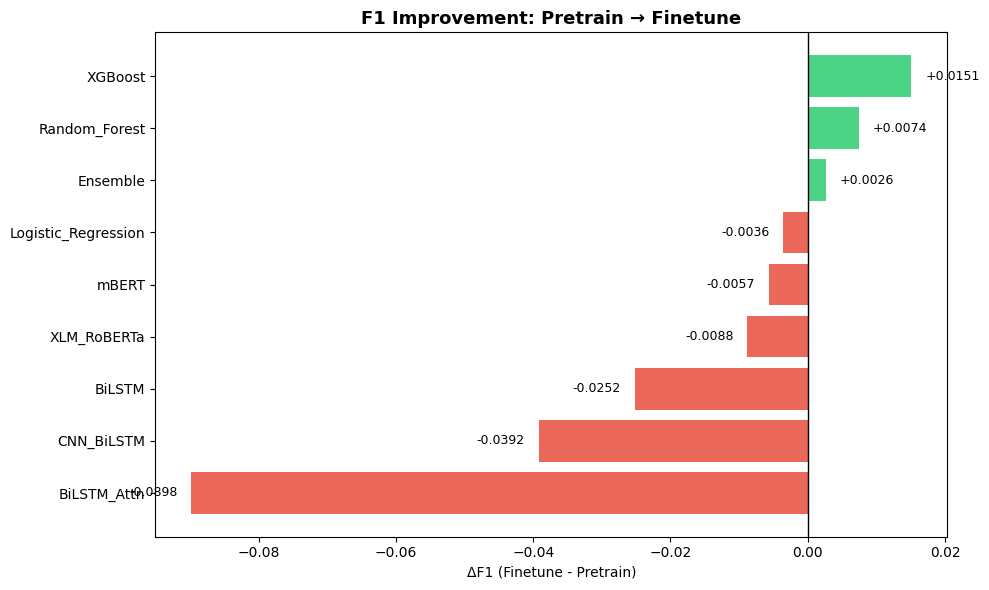

✅ Saved → f1_improvement_chart.png


In [9]:
# ══════════════════════════════════════════════════════════════
# PLOT 4 — IMPROVEMENT HEATMAP (PRETRAIN → FINETUNE)
# ══════════════════════════════════════════════════════════════
improvements = {
    name: round(summary[name]["finetune_f1"] -
                summary[name]["pretrain_f1"], 4)
    for name in summary
}

imp_df = pd.DataFrame(
    list(improvements.items()),
    columns=["Model", "F1_Improvement"]
).sort_values("F1_Improvement", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = [
    "#E74C3C" if v < 0 else "#2ECC71"
    for v in imp_df["F1_Improvement"]
]
bars = ax.barh(
    imp_df["Model"],
    imp_df["F1_Improvement"],
    color=colors_imp, alpha=0.85
)
ax.axvline(x=0, color="black", linewidth=1)
ax.set_title(
    "F1 Improvement: Pretrain → Finetune",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("ΔF1 (Finetune - Pretrain)")

for bar, val in zip(bars, imp_df["F1_Improvement"]):
    ax.text(
        bar.get_width() + 0.002 if val >= 0
        else bar.get_width() - 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{val:+.4f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("../results/figures/f1_improvement_chart.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → f1_improvement_chart.png")


Best per category:
  Traditional ML : Random_Forest
  Deep NN        : CNN_BiLSTM
  Transformer    : mBERT


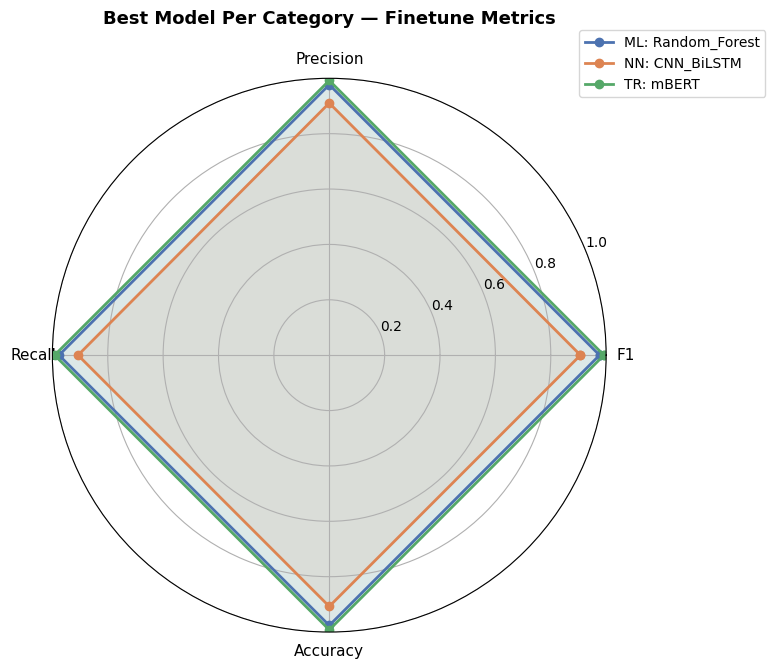

✅ Saved → radar_best_models.png


In [10]:
# ══════════════════════════════════════════════════════════════
# PLOT 5 — RADAR CHART (BEST MODEL PER CATEGORY)
# ══════════════════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch

# Pick best finetune F1 from each category
best_ml  = max(
    ["Logistic_Regression","Random_Forest","XGBoost","Ensemble"],
    key=lambda m: summary[m]["finetune_f1"]
)
best_nn  = max(
    ["BiLSTM","BiLSTM_Attn","CNN_BiLSTM"],
    key=lambda m: summary[m]["finetune_f1"]
)
best_tr  = max(
    ["mBERT","XLM_RoBERTa"],
    key=lambda m: summary[m]["finetune_f1"]
)

print(f"\nBest per category:")
print(f"  Traditional ML : {best_ml}")
print(f"  Deep NN        : {best_nn}")
print(f"  Transformer    : {best_tr}")

# Load detailed metrics for radar
# Using finetune results
radar_models = {
    f"ML: {best_ml}":    ml_results["finetune"][best_ml],
    f"NN: {best_nn}":    deep_results["finetune"][best_nn],
    f"TR: {best_tr}":    transformer_results[best_tr]["finetune"],
}

categories_radar = ["f1", "precision", "recall", "accuracy"]
labels           = ["F1", "Precision", "Recall", "Accuracy"]
N                = len(categories_radar)
angles           = [n / float(N) * 2 * np.pi for n in range(N)]
angles          += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8),
                        subplot_kw=dict(polar=True))
ax.set_title(
    "Best Model Per Category — Finetune Metrics",
    fontsize=13, fontweight="bold", pad=20
)

colors_radar = ["#4C72B0", "#DD8452", "#55A868"]
for (name, metrics_dict), color in zip(
    radar_models.items(), colors_radar
):
    values = [metrics_dict.get(c, 0) for c in categories_radar]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2,
            label=name, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("../results/figures/radar_best_models.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → radar_best_models.png")

In [11]:
# ══════════════════════════════════════════════════════════════
# FINAL SUMMARY PRINT
# ══════════════════════════════════════════════════════════════
print("\n" + "="*75)
print("  FINAL RESULTS SUMMARY")
print("="*75)

print(f"\n{'Model':<20} {'Type':<16} {'Pre_F1':>8} "
      f"{'FT_F1':>8} {'FT_Acc':>8} {'Δ F1':>8}")
print("-"*75)

for name, s in summary.items():
    pre   = s["pretrain_f1"]
    ft    = s["finetune_f1"]
    acc   = s["finetune_acc"]
    delta = ft - pre
    arrow = "↑" if delta > 0 else "↓"
    print(f"  {name:<18} {s['type']:<16} "
          f"{pre:>8.4f} {ft:>8.4f} {acc:>8.4f} "
          f"{arrow}{abs(delta):>6.4f}")

print(f"\n{'─'*75}")
print(f"  Best Pretrain F1  : "
      f"{max(summary, key=lambda m: summary[m]['pretrain_f1'])}")
print(f"  Best Finetune F1  : "
      f"{max(summary, key=lambda m: summary[m]['finetune_f1'])}")
print(f"  Best Improvement  : "
      f"{max(improvements, key=improvements.get)} "
      f"({max(improvements.values()):+.4f})")


  FINAL RESULTS SUMMARY

Model                Type               Pre_F1    FT_F1   FT_Acc     Δ F1
---------------------------------------------------------------------------
  Logistic_Regression Traditional ML     0.9665   0.9629   0.9630 ↓0.0036
  Random_Forest      Traditional ML     0.9688   0.9762   0.9762 ↑0.0074
  XGBoost            Traditional ML     0.9531   0.9683   0.9683 ↑0.0151
  Ensemble           Traditional ML     0.9710   0.9735   0.9735 ↑0.0026
  BiLSTM             Deep NN            0.9241   0.8989   0.8995 ↓0.0252
  BiLSTM_Attn        Deep NN            0.9486   0.8588   0.8598 ↓0.0898
  CNN_BiLSTM         Deep NN            0.9464   0.9072   0.9074 ↓0.0392
  mBERT              Transformer        0.9978   0.9921   0.9921 ↓0.0057
  XLM_RoBERTa        Transformer        0.9955   0.9868   0.9868 ↓0.0088

───────────────────────────────────────────────────────────────────────────
  Best Pretrain F1  : mBERT
  Best Finetune F1  : mBERT
  Best Improvement  : XGBoost (+0

In [12]:
# ── Save final summary ────────────────────────────────────────
final_summary = {
    "summary":      summary,
    "improvements": improvements,
    "best": {
        "pretrain": max(
            summary, key=lambda m: summary[m]["pretrain_f1"]
        ),
        "finetune": max(
            summary, key=lambda m: summary[m]["finetune_f1"]
        ),
    }
}
with open("../results/metrics/final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n✅ Final summary saved → final_summary.json")
print("\n🎯 Notebook 06 complete!")


✅ Final summary saved → final_summary.json

🎯 Notebook 06 complete!
